
# 01 · Data Preprocessing & Cleaning

**Goal of this notebook:** take the raw match-level feed and turn it into a clean,
analysis-ready table, while documenting *why* each cleaning decision was made
rather than just applying blind statistical defaults.

> Note on the data: the real training set is a proprietary historical
> international-football feed (2005-2024, 30k+ matches) that isn't published in
> this repo for size/licensing reasons. `generate_dummy_data.py` produces a
> synthetic dataset with the same schema and similar missingness patterns so
> every cell below runs end-to-end and the charts are real, not placeholders.

**What we'll do:**
1. First look at the raw data - shape, dtypes, missingness
2. Target & key-driver sanity checks (goals, Elo)
3. Domain-aware missing value handling (not just `fillna(0)` everywhere)
4. Confederation-aware imputation for macro-economic features
5. Outlier correction (sensor-error altitude values)
6. Datetime decomposition + categorical encoding
7. Export the cleaned table


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

import sys
sys.path.append('.')
from plot_style import set_style, PALETTE
set_style()

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)


## 1. First look at the raw data

In [2]:
df = pd.read_csv("../data/train.csv")
print(f"Shape: {df.shape[0]:,} matches x {df.shape[1]} columns")
df.head()


Shape: 6,000 matches x 42 columns


,Id,date,team,opponent,team_goals,opp_goals,is_home,neutral,tournament,gender,confederation_team,confederation_opp,venue_country,elo_team,elo_opponent,rank_team,rank_opponent,rank_diff,population_team,population_opp,gdp_per_capita_team,gdp_per_capita_opp,distance_travel_team,distance_travel_opp,temperature_venue,altitude_venue,h2h_points_last5,h2h_gd_last5,team_points_last5,opp_points_last5,points_last5_diff,team_gd_last5,opp_gd_last5,gd_last5_diff,team_points_last10,opp_points_last10,team_avg_goals_last5,team_avg_conceded_last5,opp_avg_goals_last5,opp_avg_conceded_last5,team_win_rate_last10,opp_win_rate_last10
0,0,2008-01-01 00:07:05,Paraguay,New Zealand,4,1,1,0,Nations League,male,CONMEBOL,OFC,Paraguay,1639.925066,1536.005655,80.098390,91.090576,-10.992186,7.2,5.2,5800.0,48700.0,397.235162,7415.004778,31.988893,737.814318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2008-01-03 22:27:13,Germany,South Korea,3,0,0,1,FIFA World Cup,female,UEFA,AFC,Serbia,2093.616664,1693.254611,1.000000,79.745632,-78.745632,83.0,51.0,48700.0,32400.0,NaN,3068.141611,24.358697,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2008-01-04 05:09:39,Peru,Saudi Arabia,2,0,1,0,WC Qualifiers,male,CONMEBOL,AFC,Peru,1685.969169,1630.098560,63.820325,91.321080,-27.500756,33.0,36.0,6900.0,23200.0,1811.306971,4879.191033,20.757658,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2008-01-05 15:59:46,Mexico,Nigeria,1,1,0,1,Friendly,male,CONCACAF,CAF,Peru,1843.467588,1740.847529,38.209302,70.269443,-32.060140,128.0,213.0,11500.0,2100.0,NaN,3472.888536,18.910324,5.690508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2008-01-06 14:27:25,Egypt,Portugal,3,3,1,0,Nations League,male,CAF,UEFA,Egypt,1627.989831,1941.034157,77.273270,27.439121,49.834149,109.0,10.3,4200.0,24500.0,NaN,3124.593203,22.448958,1102.472772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.dtypes.value_counts()


float64    29
str         8
int64       5
Name: count, dtype: int64

Quick dtype check - categoricals are still raw strings at this point (`team`,
`tournament`, `confederation_team`, ...), and `date` hasn't been parsed yet.
That's expected; we deal with both further down.

### Missingness overview

Before deciding *how* to impute anything, let's see *where* the gaps actually are.

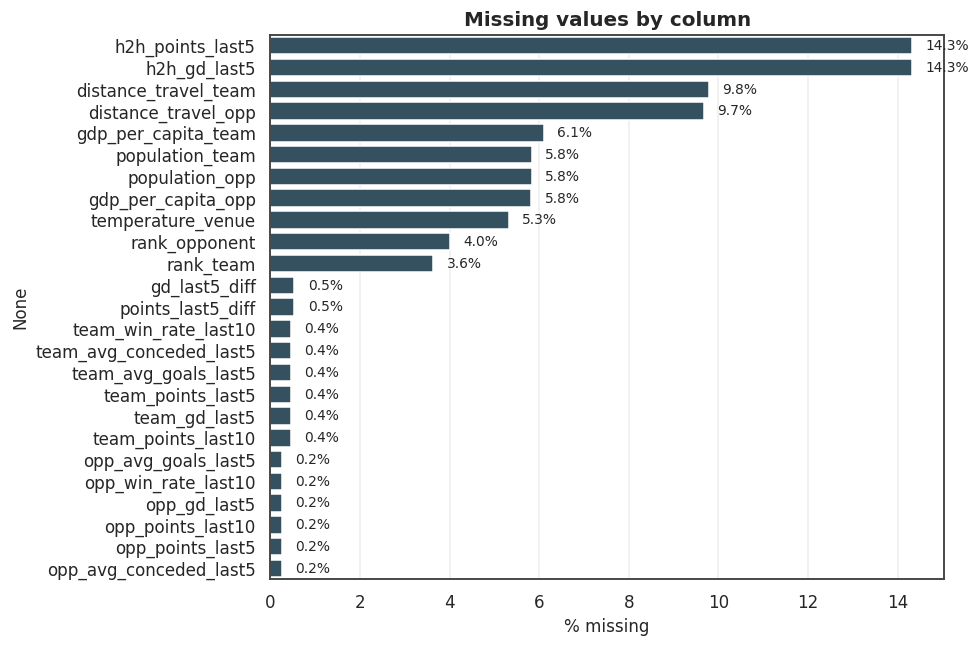

In [4]:
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=missing.values * 100, y=missing.index, color=PALETTE[0], ax=ax)
ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
for i, v in enumerate(missing.values * 100):
    ax.text(v + 0.3, i, f"{v:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()


Three distinct missingness stories show up here, and each gets a different
treatment later in this notebook:

- **`h2h_*` columns** are missing whenever two teams haven't met in the lookback
  window - this is *structural* missingness (a real "no history" signal), not
  noise. We'll flag it rather than just zero it out blindly.
- **Macro stats** (`population_*`, `gdp_per_capita_*`, `distance_travel_*`,
  `temperature_venue`) are missing because of incomplete source coverage for
  smaller federations - these get **confederation-aware** imputation instead of
  a single global mean, otherwise we'd quietly drag small countries toward the
  stats of football giants.
- **`rank_*`** gaps are mostly newly-affiliated national teams without an
  official ranking yet at match time.


## 2. Target & key-driver sanity checks

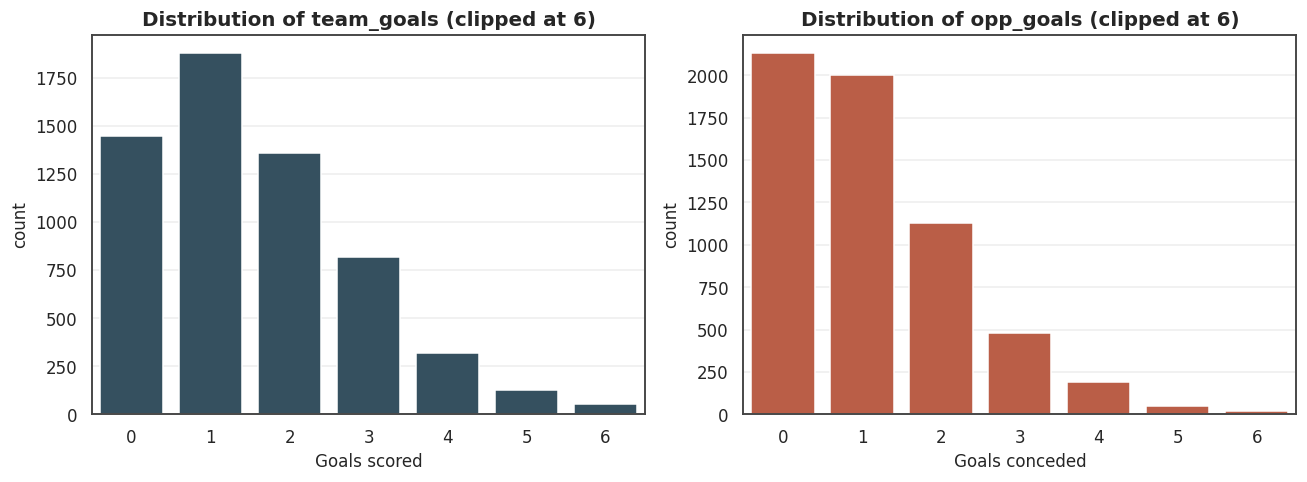

Mean team_goals: 1.551
Mean opp_goals : 1.141


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(x=df['team_goals'].clip(upper=6), color=PALETTE[0], ax=axes[0])
axes[0].set_title("Distribution of team_goals (clipped at 6)")
axes[0].set_xlabel("Goals scored")

sns.countplot(x=df['opp_goals'].clip(upper=6), color=PALETTE[5], ax=axes[1])
axes[1].set_title("Distribution of opp_goals (clipped at 6)")
axes[1].set_xlabel("Goals conceded")

plt.tight_layout()
plt.show()

print("Mean team_goals:", round(df['team_goals'].mean(), 3))
print("Mean opp_goals :", round(df['opp_goals'].mean(), 3))


Both targets are right-skewed, low-count distributions - exactly the shape
that motivated treating this as a regression-then-round problem rather than a
plain classification one; 0-1-2 goal outcomes dominate, so the model needs to
get the *common* cases right more than the rare 4+ goal blowouts.

/tmp/ipykernel_582/2033113151.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='outcome', y='elo_diff_raw', order=['Loss', 'Draw', 'Win'],


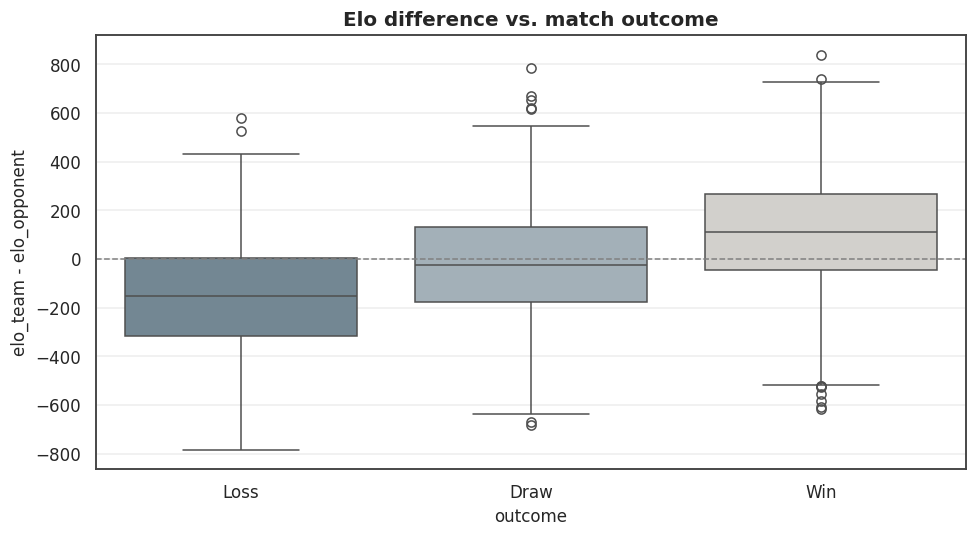

In [6]:
df['elo_diff_raw'] = df['elo_team'] - df['elo_opponent']
df['outcome'] = np.where(
    df['team_goals'] > df['opp_goals'], 'Win',
    np.where(df['team_goals'] < df['opp_goals'], 'Loss', 'Draw')
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='outcome', y='elo_diff_raw', order=['Loss', 'Draw', 'Win'],
            palette=PALETTE[1:4], ax=ax)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_title("Elo difference vs. match outcome")
ax.set_ylabel("elo_team - elo_opponent")
plt.tight_layout()
plt.show()


This is the sanity check that matters most before building any features on
top of Elo: wins skew toward positive Elo differences and losses toward
negative ones, with draws sitting in between. If this relationship weren't
monotonic, it would be a strong signal that the Elo feed itself is unreliable.

## 3. Domain-aware missing value handling

### 3.1 Head-to-head history (structural missingness -> flag, don't guess)

In [7]:
print("Matches with no prior h2h history:",
      f"{df['h2h_points_last5'].isna().mean()*100:.1f}%")

df['h2h_points_last5'] = df['h2h_points_last5'].fillna(0)
df['h2h_gd_last5'] = df['h2h_gd_last5'].fillna(0)


Matches with no prior h2h history: 14.3%


### 3.2 Rolling form features

Same logic for the rolling "last 5 / last 10" form columns: a `NaN` here
almost always means *the team simply hadn't played 5 matches yet in our
window*, not that the value is truly unknown. We zero-fill **and** keep an
explicit `_missing` indicator column so the model can still tell "no history"
apart from "genuinely had a flat run of 0s".

In [8]:
last_cols = [
    'team_points_last5', 'opp_points_last5', 'points_last5_diff',
    'team_gd_last5', 'opp_gd_last5', 'gd_last5_diff',
    'team_points_last10', 'opp_points_last10',
    'team_avg_goals_last5', 'team_avg_conceded_last5',
    'opp_avg_goals_last5', 'opp_avg_conceded_last5',
    'team_win_rate_last10', 'opp_win_rate_last10'
]

missing_rate_before = df[last_cols].isna().mean()

for col in last_cols:
    df[col + "_missing"] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(0)

print("Created", len(last_cols), "'_missing' indicator flags alongside the zero-fill.")
missing_rate_before.sort_values(ascending=False).head()


Created 14 '_missing' indicator flags alongside the zero-fill.


gd_last5_diff           0.005333
points_last5_diff       0.005333
team_gd_last5           0.004500
team_points_last5       0.004500
team_avg_goals_last5    0.004500
dtype: float64

### 3.3 Rankings

In [9]:
df['rank_team'] = df['rank_team'].fillna(-1)
df['rank_opponent'] = df['rank_opponent'].fillna(-1)
df['rank_diff'] = df['rank_diff'].fillna(0)


`-1` is used as a deliberate out-of-range sentinel for rank rather than a mean
fill - tree-based models (our eventual LightGBM/CatBoost models) can split on
this cleanly as "unranked", whereas a mean-imputed rank would silently pretend
an unranked debutant is "average".

## 4. Confederation-aware imputation for macro stats

This is the part that *can't* be a single global `.fillna(mean)` - a missing GDP-per-capita for an OFC nation shouldn't be filled with the global average, which is dragged up by Europe and pulled down by populous CAF countries. Imputing within confederation keeps each estimate geographically sane.

In [10]:
macro_cols = ['population_team', 'population_opp', 'gdp_per_capita_team', 'gdp_per_capita_opp']

# snapshot "before" for the comparison plot
before_snapshot = df[macro_cols].copy()

for col in macro_cols:
    df[col] = df.groupby('confederation_team')[col].transform(lambda x: x.fillna(x.mean()))
    df[col] = df[col].fillna(df[col].mean())  # safety net for confederations with all-NaN groups

for col in ['distance_travel_team', 'distance_travel_opp', 'temperature_venue']:
    df[col] = df[col].fillna(df[col].mean())


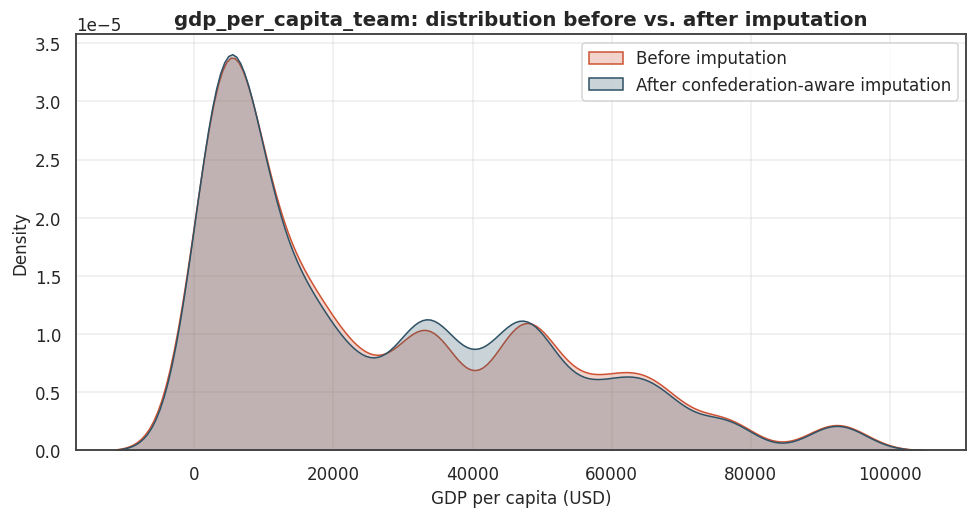

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(before_snapshot['gdp_per_capita_team'].dropna(), label='Before imputation',
            color=PALETTE[5], fill=True, alpha=0.25, ax=ax)
sns.kdeplot(df['gdp_per_capita_team'], label='After confederation-aware imputation',
            color=PALETTE[0], fill=True, alpha=0.25, ax=ax)
ax.set_title("gdp_per_capita_team: distribution before vs. after imputation")
ax.set_xlabel("GDP per capita (USD)")
ax.legend()
plt.tight_layout()
plt.show()


The post-imputation curve tracks the original shape closely instead of piling
everything onto one global spike - a quick visual confirmation that the
confederation grouping is doing its job rather than flattening the variance
we actually want the model to learn from.

## 5. Outlier correction: altitude sensor errors

110 rows (1.83%) carry the -9999 sensor-error sentinel.


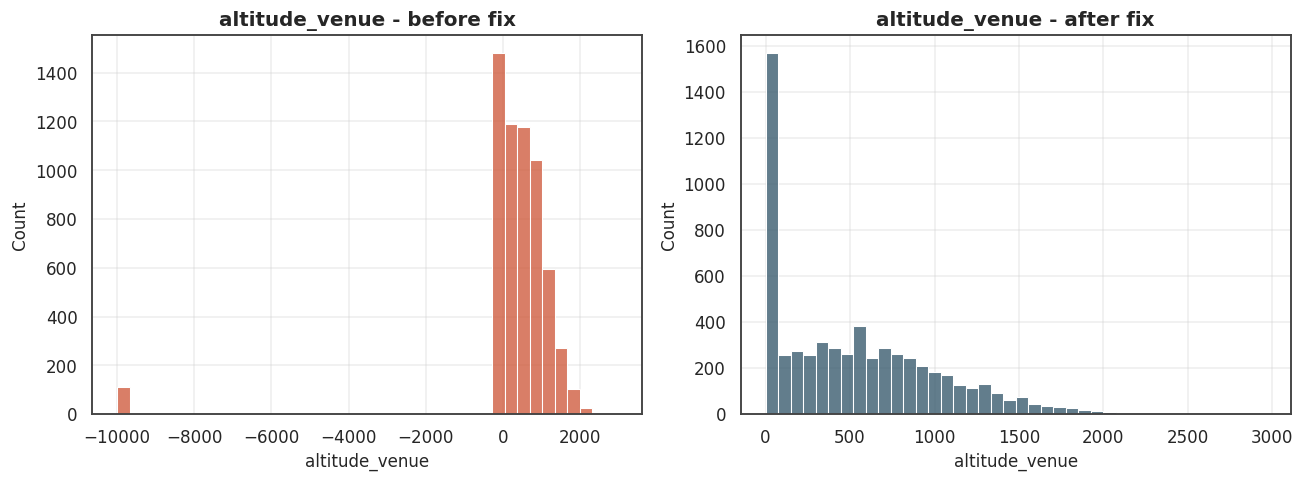

In [12]:
n_sentinel = (df['altitude_venue'] == -9999).sum()
print(f"{n_sentinel} rows ({n_sentinel/len(df)*100:.2f}%) carry the -9999 sensor-error sentinel.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['altitude_venue'], bins=40, color=PALETTE[5], ax=axes[0])
axes[0].set_title("altitude_venue - before fix")

df['altitude_venue'] = df['altitude_venue'].replace(-9999, np.nan)
df['altitude_venue'] = df['altitude_venue'].fillna(df['altitude_venue'].mean())

sns.histplot(df['altitude_venue'], bins=40, color=PALETTE[0], ax=axes[1])
axes[1].set_title("altitude_venue - after fix")
plt.tight_layout()
plt.show()


## 6. Datetime decomposition

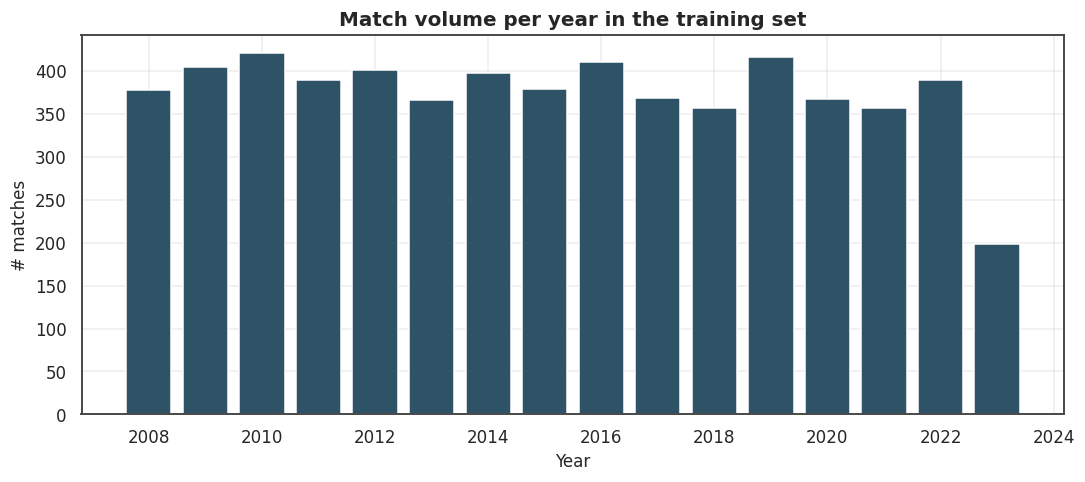

In [13]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['tahun'] = df['date'].dt.year
df['bulan'] = df['date'].dt.month

matches_per_year = df['tahun'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(matches_per_year.index, matches_per_year.values, color=PALETTE[0])
ax.set_title("Match volume per year in the training set")
ax.set_xlabel("Year")
ax.set_ylabel("# matches")
plt.tight_layout()
plt.show()


Worth keeping in mind for the train/validation split design in notebook 03:
match volume isn't perfectly uniform across years (tournament calendars and
data coverage both wobble), which is exactly why we use a **chronological**
split later instead of a random shuffle - a random split would leak
future-season form into the training fold.

## 7. Categorical encoding

In [14]:
cat_cols = ['gender', 'confederation_team', 'confederation_opp', 'tournament',
            'venue_country', 'team', 'opponent']

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

print("Encoded categoricals, e.g. tournament mapping:")
dict(zip(encoders['tournament'].classes_, encoders['tournament'].transform(encoders['tournament'].classes_)))


Encoded categoricals, e.g. tournament mapping:


{'AFC Championship': np.int64(0),
 'Copa America': np.int64(1),
 'FIFA World Cup': np.int64(2),
 'Friendly': np.int64(3),
 'Nations League': np.int64(4),
 'UEFA Euro': np.int64(5),
 'WC Qualifiers': np.int64(6)}

> **Note for future iterations:** label encoding is a deliberate, pragmatic
> choice here because the downstream models are tree-based (LightGBM /
> CatBoost), which split on raw integer codes just fine and don't assume
> ordinality the way a linear model would. If a linear or distance-based model
> ever gets added to the ensemble, these columns should switch to one-hot or
> target encoding instead.

## 8. Final check & export

In [15]:
key_cols = last_cols + ['h2h_points_last5', 'h2h_gd_last5', 'rank_team',
                         'rank_opponent', 'rank_diff'] + macro_cols + ['altitude_venue']
remaining_na = df[key_cols].isna().sum().sum()
print(f"Remaining NaNs in cleaned key columns: {remaining_na}")

df = df.drop(columns=['elo_diff_raw', 'outcome'])  # exploratory-only columns
df.to_csv("../data/train_final_ready_fix.csv", index=False)
print("Saved -> ../data/train_final_ready_fix.csv", df.shape)


Remaining NaNs in cleaned key columns: 0


Saved -> ../data/train_final_ready_fix.csv (6000, 65)
